In [1]:
### Knowledge involved
### 1) perfrom linear regression using 'sklearn' 
### 2) Basic visualization with matplotlib.pyplot
### 3) Pandas for data processing
### 4) Real-world dataset from sklearn

### Important note: check documentation of packages by yourself to learn new functions!
### e.g. for numpy: https://numpy.org/doc/stable/ 
###      for matplotlib: https://matplotlib.org/stable/api/index
###      for sklearn: https://scikit-learn.org/stable/api/index.html
###      for pandas: https://pandas.pydata.org/docs/user_guide/index.html

In [2]:
### Here we try to implement linear regression for diabete dataset.
### (It is the same example we use in Lab_4.ipynb) 
### You can consider this as a detailed explanation of the OLS example in Lab_4.ipynb

### A brief desciption of the diabete dataset can be found on:
### https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset
### It has ten features, meaning that input x has 10-dimension 
### It has a scalar output representing quantitative measure of disease,

### The data relation is not really linear but we can still try to perform OLS 

In [3]:
import numpy as np
import sklearn as sk 

### The first thing we need to do is to load the dataset from sklearn
dataset = sk.datasets.load_diabetes()

### The loaded data is a list with keywords, you can check those keywords with
print(dataset.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [15]:
### 'data' stores all the feature data (input)
### 'target' stores all the output data
### 'feature_names' stores all the name of features
### We can assign those data to new variable
x = dataset.data      ### numpy array
y = dataset.target    ### numpy array
print('input data size:', x.shape)
print('output data size:', y.shape)

### As you can see, we have 442 number of data in total
### and the input data has already been constructed as 
### 2D array with column represeting features and row representing number of data (samples)

input data size: (442, 10)
output data size: (442,)


In [4]:
### Alternatively, you can use Pandas which offer you better insight of data.
### 
import pandas as pd
x_pandas = pd.DataFrame(dataset.data, columns=dataset.feature_names)
print(x_pandas)
### As you can see, it aligns the data with feature name and demonstrates all the information to you
###

          age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  
0   -0.002592  0.019907 -0.017646  
1  

In [28]:
### Since we are dealing with real data (data are limited)
### we need to split our data into two parts: traning & test
### Training data is used for fitting the model
### Test data is used to check if the model is trained good enough
### Sklearn provide such split function
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)
### The function split data (x,y) into two parts by a ratio of 0.2 vs 0.8 

### Alternatively you can also do spliting with pandas-based data 
# X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(x_pandas, y, test_size=0.2, random_state=42)

In [29]:
### Now you can perform linear regression
### Exactly same as you did for example 2

model = sk.linear_model.LinearRegression()

### Traing model with the trainig set(input and output) 
model.fit(X_train, y_train)

### Make prediction with test dataset that model never seen before
y_pred = model.predict(X_test)

### Compute the error between model prediction and ground truth
mse = sk.metrics.mean_squared_error(y_test, y_pred)
print(mse)
### As you can see, error is quite large

2900.1936284934814


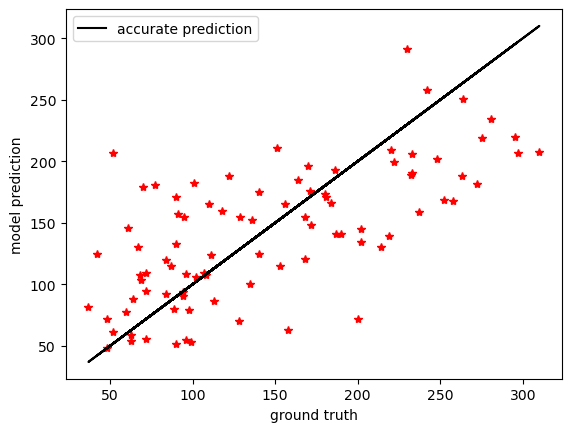

In [30]:
### We can visualize the ground truth and model prediction on test dataset
### We will plot the groundtruth y_test on x-axis
### and plot the model prediction y_pred on y-axis

import matplotlib.pyplot as plt
plt.plot(y_test,y_pred,'r*')
plt.plot(y_test,y_test,'k-',label='accurate prediction')
plt.xlabel('ground truth')
plt.ylabel('model prediction')
plt.legend()
### The black line represent where the accurate prediction should be
### but as you can see, the prediction deviate from the black line quite a lot.


In [ ]:
### Can you try to make OLS by yourself manually like we did in example 1?